# Challenge 3: Dashboard Analítico

**Nombre:** Miriam Ivonne Castañeda Chavarría
**Clase:** 3 — Visualización  
**Challenge:** 3 — Dashboard Analítico  

## Objetivo

> **El objetivo de este dashboard es responder: ¿Cómo se distribuyen las ventas de la empresa entre categorías y regiones, y cómo evolucionan a lo largo del tiempo?**

El dashboard utiliza el archivo `ventas.csv` y contiene los cinco elementos solicitados: KPI, gráfica de barras, gráfica de distribución, gráfica de relación entre variables y gráfica temporal.


## 1. Importación y preparación de datos

Se carga el dataset y se convierte `fecha` al tipo fecha para poder construir la visualización temporal.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

df = pd.read_csv("/Users/ivonnecastaneda/Downloads/ventas.csv")
df["fecha"] = pd.to_datetime(df["fecha"])

df.head()


,fecha,region_id,vendedor,producto_id,cantidad,nombre_producto,categoria,precio_unitario,total
0,2023-01-01,1,Vendedor_4,7,9,Producto 7,Electrónica,1932.73,17394.57
1,2023-01-01,3,Vendedor_10,5,5,Producto 5,Ropa,1240.04,6200.20
2,2023-01-01,5,Vendedor_6,1,1,Producto 1,Electrónica,1264.57,1264.57
3,2023-01-01,4,Vendedor_9,14,3,Producto 14,Deportes,2949.45,8848.35
4,2023-01-01,2,Vendedor_6,17,4,Producto 17,Ropa,1593.14,6372.56


### Resumen del dataset

El dataset contiene **6,000 registros**, con información desde **2023-01-01** hasta **2025-12-31**. Las variables incluyen fecha, región, vendedor, producto, cantidad, categoría, precio unitario y total de venta.


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            6000 non-null   datetime64[ns]
 1   region_id        6000 non-null   int64         
 2   vendedor         6000 non-null   object        
 3   producto_id      6000 non-null   int64         
 4   cantidad         6000 non-null   int64         
 5   nombre_producto  6000 non-null   object        
 6   categoria        6000 non-null   object        
 7   precio_unitario  6000 non-null   float64       
 8   total            6000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 422.0+ KB


## 2. Indicadores KPI

In [5]:
total_ventas = df["total"].sum()
promedio_venta = df["total"].mean()
num_transacciones = len(df)
cantidad_total = df["cantidad"].sum()

print(f"Ventas totales: ${total_ventas:,.2f}")
print(f"Venta promedio por transacción: ${promedio_venta:,.2f}")
print(f"Transacciones: {num_transacciones:,}")
print(f"Unidades vendidas: {cantidad_total:,}")


Ventas totales: $61,984,064.58
Venta promedio por transacción: $10,330.68
Transacciones: 6,000
Unidades vendidas: 36,411


### ¿Qué pregunta responde?

**¿Cuál es la magnitud general de la operación comercial?**

### Mensaje principal

Durante el periodo analizado se registran **$61,984,064.58** en ventas totales, con un promedio de **$10,330.68 por transacción**. Estos indicadores sirven como referencia para interpretar las demás gráficas.


## 3. Gráfica de barras — Ventas por categoría

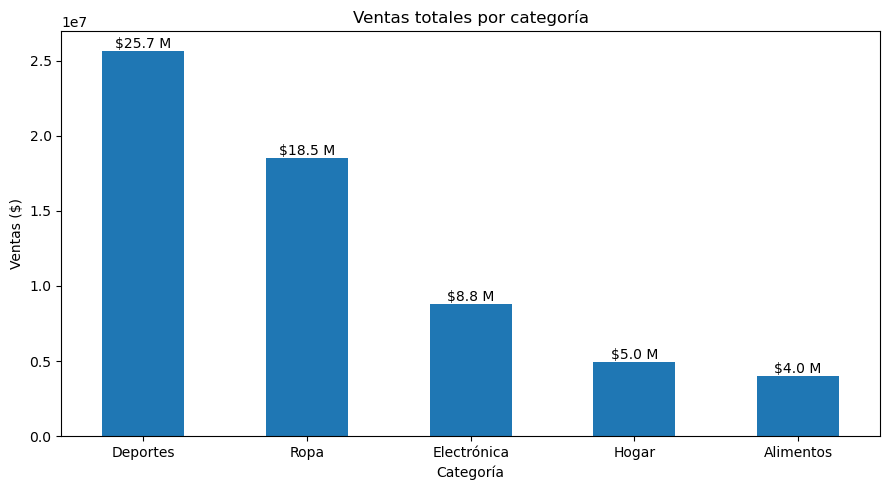

In [6]:
ventas_categoria = (df.groupby("categoria")["total"].sum().sort_values(ascending=False))
plt.figure(figsize=(9, 5))
ax = ventas_categoria.plot(kind="bar")
plt.title("Ventas totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas ($)")
plt.xticks(rotation=0)

for i, valor in enumerate(ventas_categoria):
    ax.text(i, valor, f"${valor/1e6:.1f} M", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Reflexión

**1. ¿Qué pregunta responde?**  
Permite identificar qué categorías concentran el mayor volumen de ventas.

**2. ¿Por qué elegí este tipo de gráfica?**  
La gráfica de barras facilita comparar magnitudes entre categorías discretas.

**3. ¿Cuál es el principal mensaje visual?**  
La categoría **Deportes** concentra el mayor monto de ventas, con **$25,661,252.05**. La diferencia entre categorías permite detectar dónde se concentra la actividad comercial.


## 4. Gráfica de distribución — Distribución de las ventas por transacción

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(df["total"], bins=30)
plt.title("Distribución del total de ventas por transacción")
plt.xlabel("Venta por transacción ($)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

df["total"].describe()


### Reflexión

**1. ¿Qué pregunta responde?**  
Permite observar cómo se distribuyen los montos de venta individuales.

**2. ¿Por qué elegí este tipo de gráfica?**  
Un histograma permite observar concentración, dispersión y posibles valores extremos.

**3. ¿Cuál es el principal mensaje visual?**  
Las ventas no tienen todas el mismo importe; existe dispersión entre transacciones y la distribución permite detectar si existen operaciones especialmente altas o bajas.


## 5. Gráfica de relación — Cantidad vs. total de venta

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(df["cantidad"], df["total"], alpha=0.35)
plt.title("Relación entre cantidad vendida y total de venta")
plt.xlabel("Cantidad de unidades")
plt.ylabel("Total de venta ($)")
plt.tight_layout()
plt.show()

corr_cantidad = df["cantidad"].corr(df["total"])
corr_precio = df["precio_unitario"].corr(df["total"])

print(f"Correlación cantidad-total: {corr_cantidad:.3f}")
print(f"Correlación precio unitario-total: {corr_precio:.3f}")


### Reflexión

**1. ¿Qué pregunta responde?**  
Investiga si las operaciones con mayor cantidad de unidades tienden a presentar mayores ventas totales.

**2. ¿Por qué elegí este tipo de gráfica?**  
El diagrama de dispersión permite observar directamente la relación entre dos variables numéricas.

**3. ¿Cuál es el principal mensaje visual?**  
La correlación entre `cantidad` y `total` es de aproximadamente **0.668**, lo que muestra una asociación positiva apreciable. Aun así, la relación no es perfecta porque el precio unitario también influye en el total.


## 6. Gráfica temporal — Evolución mensual de las ventas

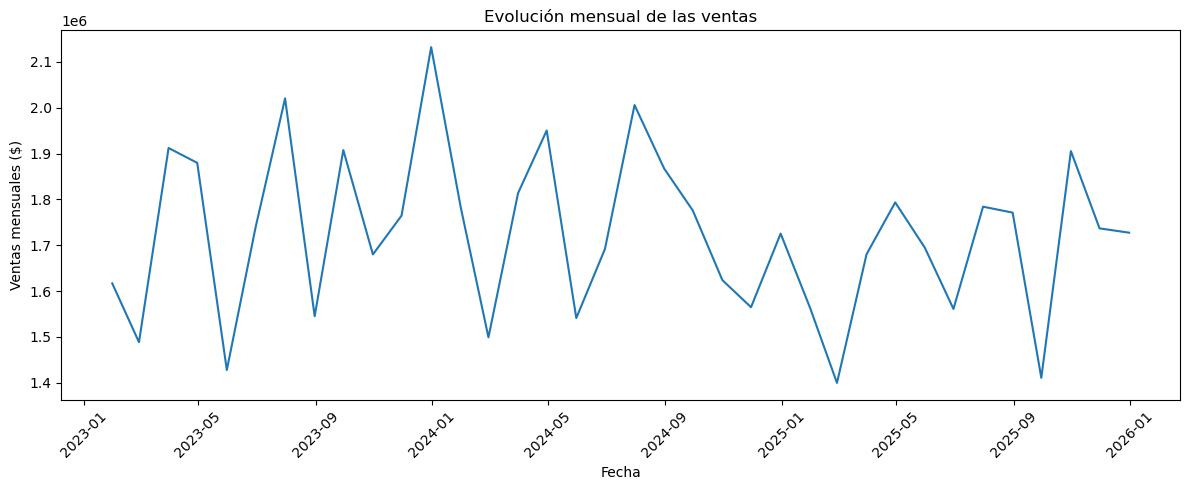

In [7]:
ventas_mensuales = (df.set_index("fecha").resample("ME")["total"].sum())

plt.figure(figsize=(12, 5))
plt.plot(ventas_mensuales.index, ventas_mensuales.values)
plt.title("Evolución mensual de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas mensuales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Reflexión

**1. ¿Qué pregunta responde?**  
Permite observar cómo cambia el nivel de ventas a través del tiempo.

**2. ¿Por qué elegí este tipo de gráfica?**  
Una línea temporal permite visualizar tendencias, aumentos y disminuciones de manera continua.

**3. ¿Cuál es el principal mensaje visual?**  
El nivel de ventas presenta variaciones mes a mes. El mes con mayor venta acumulada en el dataset fue **2023-12**, con **$2,132,455.16**.


## 7. Vista complementaria — Ventas por región

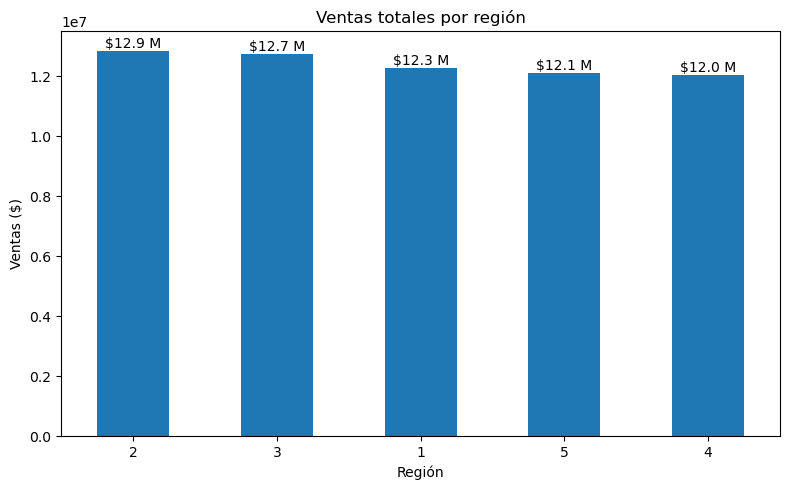

In [8]:
ventas_region = (df.groupby("region_id")["total"].sum().sort_values(ascending=False))
plt.figure(figsize=(8, 5))
ax = ventas_region.plot(kind="bar")
plt.title("Ventas totales por región")
plt.xlabel("Región")
plt.ylabel("Ventas ($)")
plt.xticks(rotation=0)

for i, valor in enumerate(ventas_region):
    ax.text(i, valor, f"${valor/1e6:.1f} M", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Conclusión

El dashboard permite analizar las ventas desde cinco perspectivas: magnitud general, categorías, distribución de las transacciones, relación entre variables y evolución temporal. Las ventas totales del periodo ascienden a **$61,984,064.58**, por lo que el KPI proporciona una referencia global para el análisis. La categoría con mayor participación en ventas es **Deportes**, mientras que la comparación regional permite revisar la concentración geográfica de los resultados. La gráfica de distribución muestra la variabilidad existente entre las operaciones individuales. Finalmente, la serie temporal evidencia que las ventas cambian de un mes a otro, por lo que el comportamiento temporal puede ser útil para análisis posteriores de tendencia y pronóstico. En conjunto, las visualizaciones convierten los datos tabulares en información que puede utilizarse para explorar el desempeño comercial.
